In [1]:
import os, time

import math
import numpy as np
from numpy.polynomial.hermite import hermgauss
from scipy.optimize import newton

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable 

from skrmt.ensemble.spectral_law import MarchenkoPasturDistribution

# Following options are dependant on https://github.com/chanjure/global_chanju.git
# However, this is just an aesthetic package for plotting, so it is not necessary.
from global_chanju.paulplot.styles import nice_style
from global_chanju.paulplot.rc_setter import set_rc
from global_chanju.paulplot.rc_setter import get_rc
from global_chanju.utils.statistics import asym_err
from global_chanju.utils.statistics import f_bin
from global_chanju.paulplot.styles import base_ten


set_rc() # Setting global chanju plotting scheme

In [2]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=200):
    new_cmap = LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# -1. Directory setup

In [3]:
plot_dir6 = "../images/4.stationary/"
data_dir6 = "../data/4.stationary/"

os.system("mkdir -p " + plot_dir6)
os.system("mkdir -p " + data_dir6)

0

# 5. Stationary limit

In [4]:
# ==========================================
# 1. System Parameters
# ==========================================
N = 4000
c = 0.5  
M = int(N / c)
eta = 1e-6

# ==========================================
# w. Matrix Generators
# ==========================================
def generate_wishart(N, c, sigma):
    M = int(N / c)
    X = np.random.normal(0., sigma/np.sqrt(M), size=(N, M))
    return X @ X.T

def generate_goe_inv(N, sigma):
    X = np.random.normal(0., sigma/np.sqrt(N), size=(N, N))
    X = (X + X.T) / np.sqrt(2)
    return np.linalg.inv(X)

# ==========================================
# 3. Direct S-Transform Solver
# ==========================================
def direct_s_transform(z_vals, r_funcs):
    t_out = np.zeros_like(z_vals, dtype=complex)
    t_guess = eta # t = zg - 1, in z >>1 limit g ~ 1/z
    
    for i in range(len(z_vals)-1, -1, -1): # Why from the last?
        z = z_vals[i]
        def eq(t):
            return 1./(z * math.prod(r(t) for r in r_funcs) - 1) - t # \sum_i R_i + 1/g - z = 0, i for different matrices
        
        try:
            t_sol = newton(eq, t_guess, maxiter=500)
            t_guess = t_sol 
            t_out[i] = t_sol
        except RuntimeError:
            t_out[i] = np.nan
            
    return t_out

# ==========================================
# 4. S-Transform Definitions
# ==========================================
def S_wishart(t, sigma, r):
    return 1./(sigma**2 * (1 + r * t))

def S_wigner_inv_sq(t, sigma):
    return - sigma**2 * t

    
def inv_WW(x, r):
    return np.sqrt(4*(x + r) - r**2) / (2 * np.pi * x *(x + r))

Calculating theoretical density...
done
Saved the figure to ../data/4.stationary/fig_H1.00_F1.00.npz


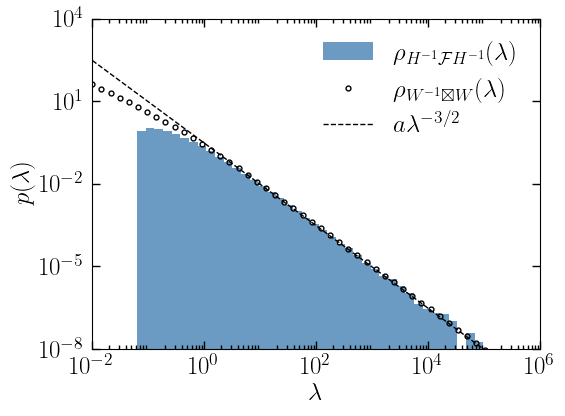

In [5]:
sigma_goe = 1.
sigma_wis = 1.

figure_id = "H%.2f_F%.2f"%(sigma_goe, sigma_wis)


try:
    with np.load(data_dir6+"fig_"+figure_id+".npz") as data:
        y_hist = data["y_hist"]
        
    print("Loaded the figure from "+data_dir6+"fig_"+figure_id+".npz")
    
except:
    # ==========================================
    # 5. Solving and Plotting
    # ==========================================
    print("Calculating theoretical density...")
    s_funcs = [
        lambda t: S_wigner_inv_sq(t, sigma_goe),
        lambda t: S_wishart(t, sigma_wis, c)
    ]

    Wigner_inv = generate_goe_inv(N, sigma_goe)
    Wishart = generate_wishart(N, c, sigma_wis)

    M_prod = Wigner_inv @ Wishart @ Wigner_inv.T 
    evals = np.linalg.eigvalsh(M_prod)

    max_eig = max(abs(evals))
    min_eig = min(evals)
    x_vals = np.linspace(min_eig - 1, max_eig + 1, 2000)
    z_vals = x_vals + 1j * eta

    t_vals = direct_s_transform(z_vals, s_funcs)
    g_vals = (1. + t_vals) / z_vals
    rho_vals = -g_vals.imag / np.pi
    print("done")
    
    y_hist = evals.flatten()
    
    np.savez(data_dir6+"fig_"+figure_id+".npz", 
             y_hist = y_hist,
            )
    print("Saved the figure to "+data_dir6+"fig_"+figure_id+".npz")

set_rc(scale=1)
n_fig=1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W'],
             get_rc()['W']*get_rc()['r']),
)

n_bin, xran, bins, _ = f_bin(y_hist, logscale=True)

axs.hist(y_hist, bins=bins, range=xran, density=True,
         color='steelblue', alpha=0.8, 
         label=r"$\rho_{H^{-1} \mathcal{F} H^{-1}} (\lambda)$"
#          label=r"$\sigma_{\mathcal{F}}: %.2f, \sigma_H: %0.2f$"%(sigma_wis, sigma_goe)
        )

x_plot = np.logspace(-2, 6)

y_plot = inv_WW(x_plot, c)
axs.plot(x_plot, y_plot, 
         marker='.', ls='', color='k', clip_on=True,
         label=r"$\rho_{W^{-1} \boxtimes W} (\lambda)$")

axs.plot(x_plot, 0.3*x_plot**-1.5, 
         marker='', ls='--', color='k',
         label=r"$a \lambda^{-3/2}$")


nice_style(axs, 
           ylim=(1e-8, 1e4),
           xlim=(1e-2, 1e6),
           xlabel=r"$\lambda$",
           ylabel=r"$p(\lambda)$",
           logx=True, logy=True
          )

plt.legend(loc='upper right', facecolor='white', framealpha=1., frameon=False)

plt.savefig(plot_dir6 + figure_id+".pdf", bbox_inches="tight")

plt.show()